### Conectar con google drive + instalar pymgrid

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

ruta_directorio = '/content/drive/MyDrive/3.Hiruhilekoa/RETO3-SistemaGestiónMicrored/objetivo1'

os.chdir(ruta_directorio)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración visual para que las gráficas queden de 10
plt.style.use('seaborn-v0_8-darkgrid')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



# Bins para la carga neta


--- RESULTADOS CARGA NETA ---
Mínimo (Máx excedente solar): -1018.86 kW
Máximo (Pico de consumo): 62.44 kW
BINS CALCULADOS: [-426.61, -75.55, 15.02, 38.4]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



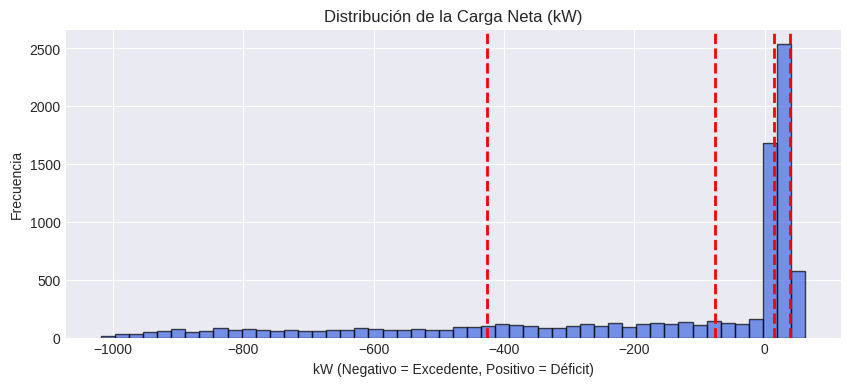

In [ ]:
df_load = pd.read_csv('./data/pymgrid_data/load/RefBldgFullServiceRestaurantNew2004_v1.3_7.1_6A_USA_MN_MINNEAPOLIS.csv')
df_pv = pd.read_csv('./data/pymgrid_data/pv/SanFrancisco_724940TYA.csv')

# 2. Extraer directamente los valores de la primera columna (índice 0)
load_kw = df_load.iloc[:, 0].values
pv_kw = df_pv.iloc[:, 0].values

# 3. Calcular la carga neta del año completo
carga_neta = load_kw - pv_kw

# 4. Calcular los percentiles (25%, 50%, 75%)
bins_carga = np.round(np.percentile(carga_neta, [20, 40, 60, 80]), 2)

print("\n--- RESULTADOS CARGA NETA ---")
print(f"Mínimo (Máx excedente solar): {carga_neta.min():.2f} kW")
print(f"Máximo (Pico de consumo): {carga_neta.max():.2f} kW")
print(f"BINS CALCULADOS: {bins_carga.tolist()}")

# 5. Visualización rápida
plt.figure(figsize=(10, 4))
plt.hist(carga_neta, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
for b in bins_carga:
    plt.axvline(b, color='red', linestyle='dashed', linewidth=2)
plt.title("Distribución de la Carga Neta (kW)")
plt.xlabel("kW (Negativo = Excedente, Positivo = Déficit)")
plt.ylabel("Frecuencia")
plt.show()

# Bins para el precio


--- RESULTADOS PRECIOS DE ENERGÍA ---
Precio Mínimo: 0.0206 €/kWh
Precio Máximo: 0.4231 €/kWh
BINS CALCULADOS: [0.097, 0.134, 0.164]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



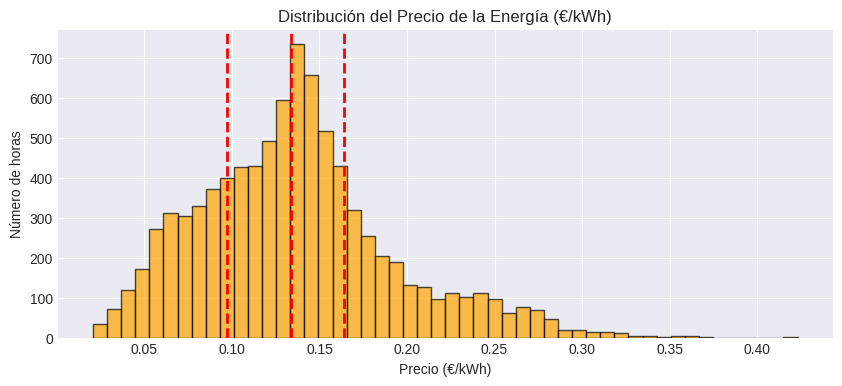

In [ ]:
df_precios = pd.read_csv('./data/precio2025-peninsula.csv', sep=';')

# 2. Extraer el valor y convertir de €/MWh a €/kWh
precios_kwh = df_precios['value'].values / 1000.0

# 3. Calcular los percentiles (cuartiles 25%, 50%, 75%)
bins_precio = np.round(np.percentile(precios_kwh, [25, 50, 75]), 3)

print("\n--- RESULTADOS PRECIOS DE ENERGÍA ---")
print(f"Precio Mínimo: {precios_kwh.min():.4f} €/kWh")
print(f"Precio Máximo: {precios_kwh.max():.4f} €/kWh")
print(f"BINS CALCULADOS: {bins_precio.tolist()}")

# 4. Visualización de la volatilidad del precio
plt.figure(figsize=(10, 4))
plt.hist(precios_kwh, bins=50, color='orange', edgecolor='black', alpha=0.7)
for b in bins_precio:
    plt.axvline(b, color='red', linestyle='dashed', linewidth=2)
plt.title("Distribución del Precio de la Energía (€/kWh)")
plt.xlabel("Precio (€/kWh)")
plt.ylabel("Número de horas")
plt.show()